In [15]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [16]:
digits = load_digits()

X = digits.data
y = digits.target

print(X.shape)

(1797, 64)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
pca = PCA(n_components=41)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)  # Confirms alignment with training components

In [30]:
print(pca.explained_variance_ratio_)

[0.12038006 0.09733098 0.08561821 0.06493777 0.04887914 0.04264048
 0.03949359 0.03349634 0.03023564 0.02931935 0.02772034 0.02544597
 0.02303063 0.02284083 0.02121741 0.01896257 0.01747417 0.01604341
 0.0158501  0.01508824 0.01339746 0.01273262 0.01138241 0.01043294
 0.00985377 0.00937385 0.00853172 0.00836261 0.00797069 0.00757462
 0.007004   0.00690267 0.00642917 0.00612906 0.00574282 0.00537687
 0.00502651 0.00476078 0.0045189  0.00429742 0.00410624]


In [31]:
# Import LogisticRegression from scikit-learn
from sklearn.linear_model import LogisticRegression

# Create LogisticRegression instance without multi_class parameter
# (multi_class='auto' is the default behavior in newer versions)
clf = LogisticRegression(
    max_iter=1000  # Removed multi_class parameter
)

clf.fit(X_train_pca, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [32]:
y_pred = clf.predict(X_test_pca)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9638888888888889


In [33]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[33  0  0  0  0  0  0  0  0  0]
 [ 0 27  1  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 33  0  1  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 44  1  0  0  2]
 [ 0  0  0  0  0  1 34  0  0  0]
 [ 0  0  0  0  0  1  0 33  0  0]
 [ 0  2  0  0  0  1  0  0 27  0]
 [ 0  0  0  1  0  0  0  0  2 37]]


In [34]:
!pip install mlxtend

In [35]:
!pip install --upgrade matplotlib


In [36]:
!pip install --upgrade mlxtend

C:\Users\OMKAR\anaconda3\Lib\site-packages\mlxtend\plotting\decision_regions.py:352: UserWarning: You passed an edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


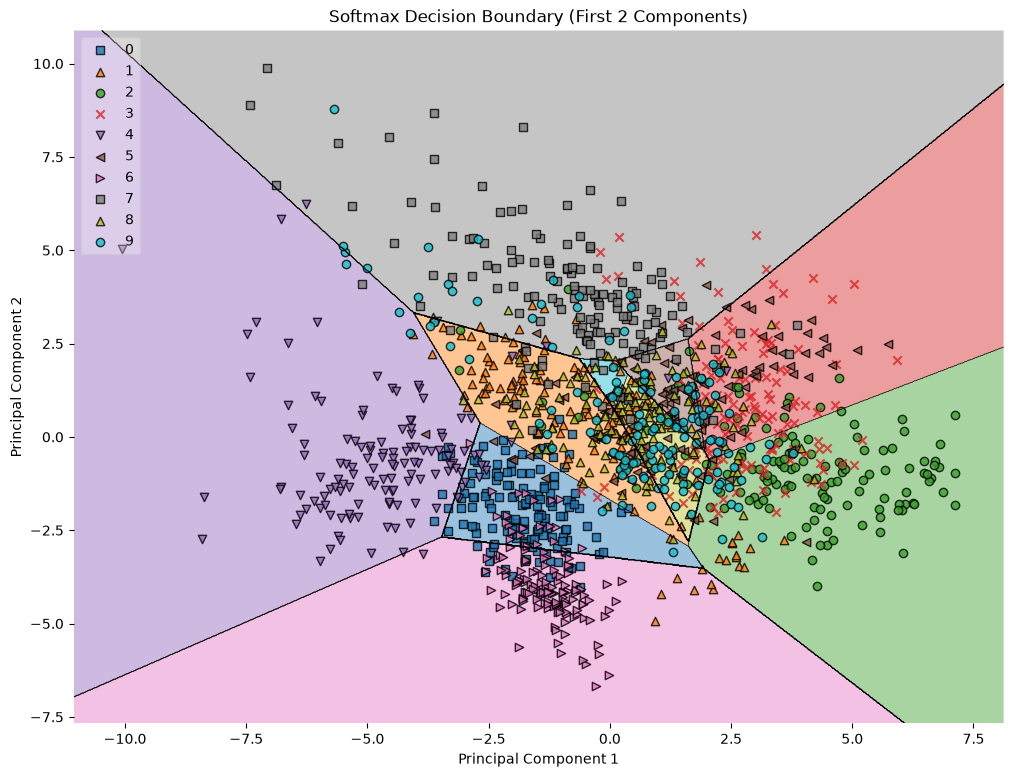

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
from sklearn.linear_model import LogisticRegression

# 1. Take only the first 2 principal components
X_plot = np.array(X_train_pca[:, :2])
y_plot = np.array(y_train).astype(int).flatten()

# 2. Train a temporary 2D classifier just for visualization (multi_class removed)
clf_2d = LogisticRegression(solver='lbfgs')
clf_2d.fit(X_plot, y_plot)

# 3. Plot the decision regions
plt.figure(figsize=(12, 9))
plot_decision_regions(X_plot, y_plot, clf=clf_2d, legend=2)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Softmax Decision Boundary (First 2 Components)")
plt.show()

In [40]:
components = pca.components_

print(components.shape)

(41, 64)


In [41]:
for i, component in enumerate(components):
    top_features = np.argsort(np.abs(component))[::-1][:10]

    print(f"\nPrincipal Component {i+1}")
    print(top_features)


Principal Component 1
[ 2 58  9 33 34 10  3 59  1 26]

Principal Component 2
[ 5 14  6 60 54 61 46 13 42 50]

Principal Component 3
[43 35 44 36 38 19 51 53 46 45]

Principal Component 4
[61 25 28 18 20 10 57 33 54  1]

Principal Component 5
[15  7 23 55 62 63 12 20  6 54]

Principal Component 6
[49 48 31 57 23  1 40 15 41 52]

Principal Component 7
[26 25 51 17 27  3 50 42 21 38]

Principal Component 8
[63 52 35 46 27 44 62 21 34 55]

Principal Component 9
[16 24 12 31  8 57  1 23 15 17]

Principal Component 10
[16 11 50 48 40 24 53 19  8 18]

Principal Component 11
[48  5 56 30 20 12 38 49 23 13]

Principal Component 12
[48 31 27 59 42 16  3 28 40 61]

Principal Component 13
[47 36 19 55 27 38 57 23 24 56]

Principal Component 14
[45  4 37 52 11 59 36 16 46  3]

Principal Component 15
[24 16 12 17  9 51  4 59 27 25]

Principal Component 16
[ 8 47  4 55 24 56 35 27 13 22]

Principal Component 17
[56 40  6 36 35 57 41  7 23 29]

Principal Component 18
[56  8 40 24 29 21 36 18  1 61]



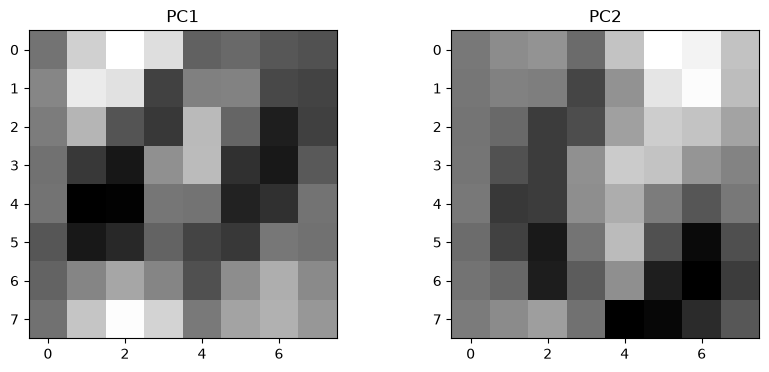

In [42]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(pca.components_[0].reshape(8,8), cmap='gray')
plt.title("PC1")

plt.subplot(1,2,2)
plt.imshow(pca.components_[1].reshape(8,8), cmap='gray')
plt.title("PC2")

plt.show()